<a href="https://colab.research.google.com/github/dimsdims29/msdocs-flask-postgresql-sample-app-azd/blob/main/Advanced_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.	Lakukan analisis eksplorasi data pada dataset tersebut dan berikan penjelasan dan visualisasinya menggunakan python

a.	Jalankan fungsi-fungsi dasar: info(), describe().

In [1]:
import pandas as pd

# Load data
df = pd.read_csv('cust_seg.csv')

# Info data untuk menampilkan tipe data tiap kolom, jumlah baris,
# dan missing values.
df.info()

# Statistik deskriptif untuk menampilkan statistik deskriptif
# (mean, std, min, max) untuk kolom numerik.
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   custid               200 non-null    int64  
 1   sex                  200 non-null    int64  
 2   AqChannel            200 non-null    int64  
 3   region               200 non-null    int64  
 4   Marital_status       200 non-null    int64  
 5   segment              200 non-null    int64  
 6   pre_usage            200 non-null    int64  
 7   Post_usage_1month    200 non-null    int64  
 8   Latest_mon_usage     200 non-null    float64
 9   post_usage_2ndmonth  200 non-null    float64
dtypes: float64(2), int64(8)
memory usage: 15.8 KB


,custid,sex,AqChannel,region,Marital_status,segment,pre_usage,Post_usage_1month,Latest_mon_usage,post_usage_2ndmonth
count,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.54500,3.430000,2.055000,1.160000,2.025000,52.230000,52.775000,63.174000,58.052500
std,57.879185,0.49922,1.039472,0.724291,0.367526,0.690477,10.252937,9.478586,11.242137,10.426445
min,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,28.000000,31.000000,39.600000,34.100000
25%,50.750000,0.00000,3.000000,2.000000,1.000000,2.000000,44.000000,45.750000,54.000000,50.325000
50%,100.500000,1.00000,4.000000,2.000000,1.000000,2.000000,50.000000,54.000000,62.400000,59.400000
75%,150.250000,1.00000,4.000000,3.000000,1.000000,2.250000,60.000000,60.000000,70.800000,66.000000
max,200.000000,1.00000,4.000000,3.000000,2.000000,3.000000,76.000000,67.000000,90.000000,73.700000


b.	Buat histogram untuk melihat persebaran data beberapa variable yang menurut Anda penting.

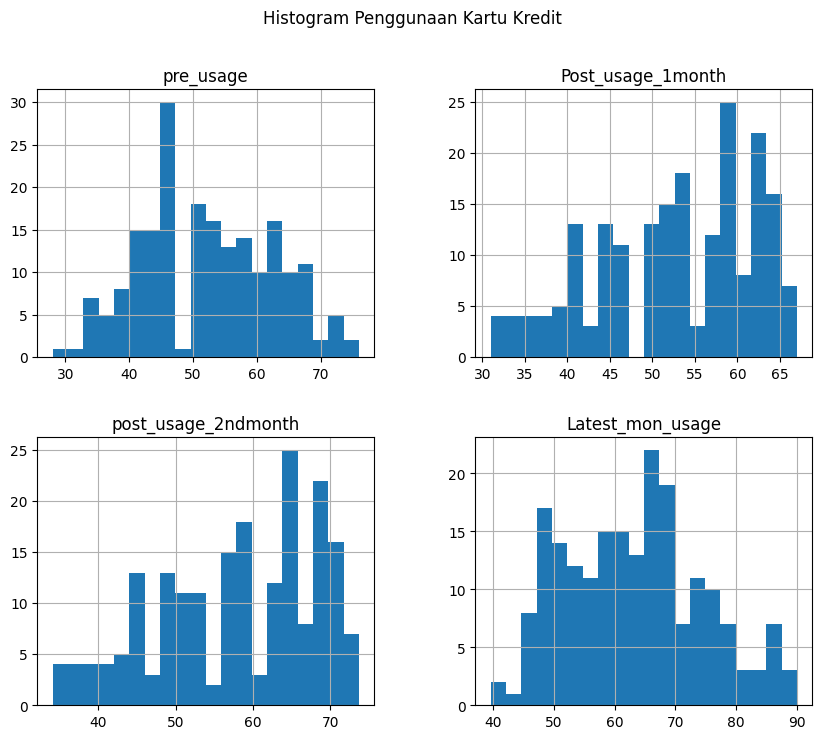

In [2]:
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv('cust_seg.csv')

# Pilih variabel penting
cols = ['pre_usage', 'Post_usage_1month', 'post_usage_2ndmonth', 'Latest_mon_usage']

df[cols].hist(bins=20, figsize=(10,8))
plt.suptitle("Histogram Penggunaan Kartu Kredit")
plt.show()

# Histogram digunakan untuk melihat distribusi data apakah normal/skewed
# dan digunakan untuk melihat perbandingan sebelum dan sesudah campaign

#2.	Lakukan uji hipotesis untuk melihat apakah kampanye yang dilakukan berhasil. (Hint: gunakan fungsi ttest_rel):

a.	Bandingkan penggunaan kartu kredit antara sebelum kampanye dengan 1 bulan setelah kampanye.

In [3]:
from scipy.stats import ttest_rel
import pandas as pd


df = pd.read_csv('cust_seg.csv')


stat, p_value = ttest_rel(df['pre_usage'], df['Post_usage_1month'])

print("T-statistic:", stat)
print("P-value:", p_value)
print("\n")

# Hipotesis:
# H0: Tidak ada perbedaan penggunaan sebelum dan 1 bulan setelah campaign
# H1: Ada perbedaan penggunaan sebelum dan 1 bulan setelah campaign

alpha = 0.05

if p_value < alpha:
    print("Tolak H0 = Campaign berpengaruh (signifikan)")
else:
    print("Gagal tolak H0 = Campaign tidak signifikan")

print("\n")


T-statistic: -0.8673065458794775
P-value: 0.3868186820914985


Gagal tolak H0 = Campaign tidak signifikan




b.	Bandingkan penggunaan kartu kredit antara sebelum kampanye dengan 2 bulan setelah kampanye.

In [ ]:
from scipy.stats import ttest_rel
import pandas as pd


df = pd.read_csv('cust_seg.csv')


stat, p_value = ttest_rel(df['pre_usage'], df['post_usage_2ndmonth'])

print("T-statistic:", stat)
print("P-value:", p_value)
print("\n")

# Hipotesis:
# H0: Tidak ada perbedaan penggunaan sebelum dan 2 bulan setelah campaign
# H1: Ada perbedaan penggunaan

alpha = 0.05

if p_value < alpha:
    print("Tolak H0 = Campaign berpengaruh (signifikan)")
else:
    print("Gagal tolak H0 = Campaign tidak signifikan")

print("\n")


T-statistic: -8.866832246938742
P-value: 4.295733828012836e-16


Tolak H0 = Campaign berpengaruh (signifikan)




# 3.	Lakukan uji hipotesis untuk melihat apakah ada perbedaan penggunaan kartu kredit antara kelompok laki-laki dan perempuan setelah kampanye. (Hint: gunakan fungsi ttest_ind):

a.	Bandingkan penggunaan kartu kredit kelompok laki-laki dengan perempuan 1 bulan setelah kampanye.

In [4]:
from scipy.stats import ttest_ind
import pandas as pd


df = pd.read_csv('cust_seg.csv')

male = df[df['sex'] == 0]
female = df[df['sex'] == 1]

stat, p_value = ttest_ind(male['Post_usage_1month'], female['Post_usage_1month'])

print("T-statistic:", stat)
print("P-value:", p_value)
print("\n")

# Hipotesis:
# H0: Tidak ada perbedaan penggunaan antara laki-laki dan perempuan
# H1: Ada perbedaan penggunaan

alpha = 0.05

if p_value < alpha:
    print("Tolak H0 = Ada perbedaan signifikan")
else:
    print("Gagal tolak H0 = Tidak ada perbedaan signifikan")

print("\n")


T-statistic: -3.7340738531536797
P-value: 0.00024625461203549315


Tolak H0 = Ada perbedaan signifikan




b.	Bandingkan penggunaan kartu kredit kelompok laki-laki dengan perempuan 2 bulan setelah kampanye.

In [5]:
from scipy.stats import ttest_ind
import pandas as pd


df = pd.read_csv('cust_seg.csv')

male = df[df['sex'] == 0]
female = df[df['sex'] == 1]

stat, p_value = ttest_ind(male['post_usage_2ndmonth'], female['post_usage_2ndmonth'])

print("T-statistic:", stat)
print("P-value:", p_value)
print("\n")

# Hipotesis:
# Jika p-value < 0.05 : campaign berhasil mempengaruhi penggunaan
# Jika p-value > 0.05 : campaign tidak signifikan
# Perbandingan gender: melihat apakah campaign efektif untuk segmen tertentu

alpha = 0.05

if p_value < alpha:
    print("Tolak H0 = Ada perbedaan signifikan")
else:
    print("Gagal tolak H0 = Tidak ada perbedaan signifikan")

print("\n")


T-statistic: -3.7340738531536926
P-value: 0.00024625461203548154


Tolak H0 = Ada perbedaan signifikan


